[Parallel(n_jobs=-1)]: Using backend LokyBackend with 61 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of 961 | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done  23 out of 961 | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  40 out of 961 | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done  59 out of 961 | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done  78 out of 961 | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done  99 out of 961 | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 120 out of 961 | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done 143 out of 961 | elapsed:   13.5s
[Parallel(n_jobs=-1)]: Done 166 out of 961 | elapsed:   14.7s
[Parallel(n_jobs=-1)]: Done 191 out of 961 | elapsed:   16.6s
[Parallel(n_jobs=-1)]: Done 216 out of 961 | elapsed:   17.7s
[Parallel(n_jobs=-1)]: Done 243 out of 961 | elapsed:   18.8s
[Parallel(n_jobs=-1)]: Done 270 out of 961 | elapsed:   21.3s
[Parallel(n_jobs=-1)]: Done 299 out of 961 | elapsed:   22.8s
[Parallel(n_jobs=-1)]: Done 328 out of 961 | elapsed:  

Hardening mean threshold below Omega=1: nan
Hardening mean threshold above Omega=1: nan


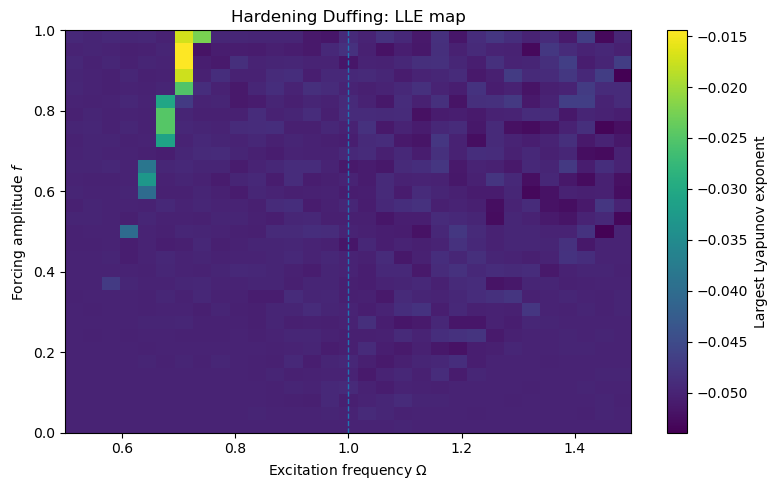

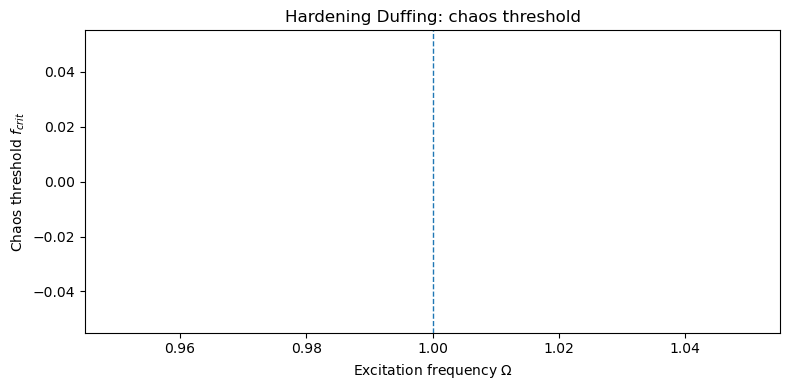

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 61 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of 961 | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  23 out of 961 | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  40 out of 961 | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  59 out of 961 | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  78 out of 961 | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done  99 out of 961 | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 120 out of 961 | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 143 out of 961 | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done 166 out of 961 | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 191 out of 961 | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 216 out of 961 | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 243 out of 961 | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 270 out of 961 | elapsed:   10.8s
[Parallel(n_jobs=-1)]: Done 299 out of 961 | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done 328 out of 961 | elapsed:  

Softening mean threshold below Omega=1: nan
Softening mean threshold above Omega=1: nan


[Parallel(n_jobs=-1)]: Done 961 out of 961 | elapsed:   18.3s finished


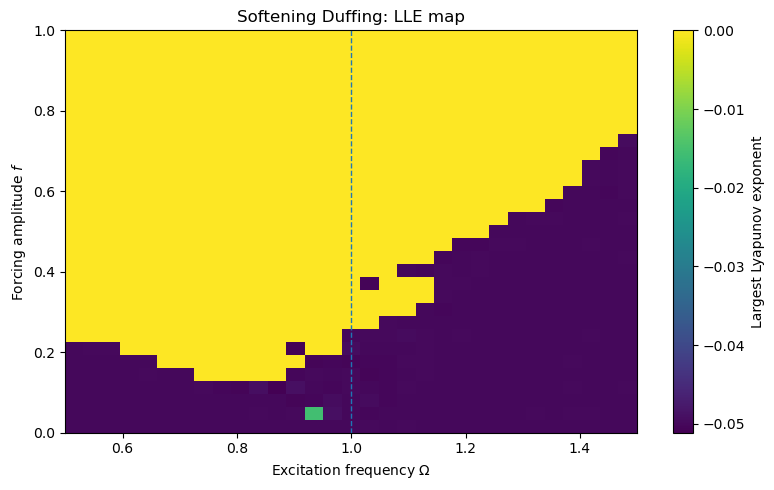

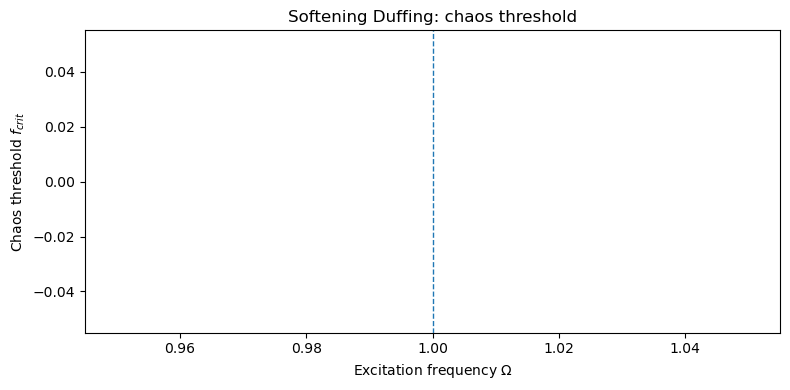

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from dataclasses import dataclass
from joblib import Parallel, delayed


@dataclass
class DuffingParams:
	zeta: float = 0.05
	beta: float = 1.0
	omega: float = 1.0
	forcing: float = 0.2


@dataclass
class SimulationParams:
	n_transient: int = 500
	n_sample: int = 200
	points_per_period: int = 100
	rtol: float = 1e-9
	atol: float = 1e-11
	lyapunov_threshold: float = 1e-3


def duffing_rhs(t, y, params):
	x, v = y
	zeta = params.zeta
	beta = params.beta
	Omega = params.omega
	f = params.forcing

	dxdt = v
	dvdt = -2.0 * zeta * v - x - beta * x**3 + f * np.cos(Omega * t)

	return np.array([dxdt, dvdt])


def duffing_variational_rhs(t, y_aug, params):
	x = y_aug[0]
	v = y_aug[1]
	w = y_aug[2:4]

	zeta = params.zeta
	beta = params.beta
	Omega = params.omega
	f = params.forcing

	dxdt = v
	dvdt = -2.0 * zeta * v - x - beta * x**3 + f * np.cos(Omega * t)

	A = np.array([
		[0.0, 1.0],
		[-1.0 - 3.0 * beta * x**2, -2.0 * zeta]
	])

	dwdt = A @ w

	return np.concatenate(([dxdt, dvdt], dwdt))


def integrate_duffing(params, sim, z0):
	T = 2.0 * np.pi / params.omega
	t_end = (sim.n_transient + sim.n_sample) * T
	max_step = T / sim.points_per_period

	sol = solve_ivp(
		lambda t, y: duffing_rhs(t, y, params),
		(0.0, t_end),
		z0,
		rtol=sim.rtol,
		atol=sim.atol,
		max_step=max_step,
		dense_output=True
	)

	return sol


def poincare_points(params, sim, z0):
	T = 2.0 * np.pi / params.omega
	sol = integrate_duffing(params, sim, z0)

	sample_indices = np.arange(sim.n_transient, sim.n_transient + sim.n_sample + 1)
	t_sample = sample_indices * T
	z_sample = sol.sol(t_sample).T

	return z_sample, sol


def largest_lyapunov_exponent(params, sim, z0, perturbation_norm=1e-8):
	T = 2.0 * np.pi / params.omega
	max_step = T / sim.points_per_period

	z = np.array(z0, dtype=float)
	w = np.array([perturbation_norm, 0.0], dtype=float)

	log_sum = 0.0
	total_time = 0.0
	t0 = 0.0

	for k in range(sim.n_transient + sim.n_sample):
		y_aug0 = np.concatenate((z, w))

		sol = solve_ivp(
			lambda t, y: duffing_variational_rhs(t, y, params),
			(t0, t0 + T),
			y_aug0,
			rtol=sim.rtol,
			atol=sim.atol,
			max_step=max_step
		)

		z = sol.y[0:2, -1]
		w = sol.y[2:4, -1]

		w_norm = np.linalg.norm(w)

		if w_norm == 0.0 or not np.isfinite(w_norm):
			return np.nan

		if k >= sim.n_transient:
			log_sum += np.log(w_norm / perturbation_norm)
			total_time += T

		w = perturbation_norm * w / w_norm
		t0 += T

	return log_sum / total_time


def classify_from_lle(lle, threshold=1e-3):
	if not np.isfinite(lle):
		return -1
	if lle > threshold:
		return 1
	return 0


def compute_lle_grid_point(i, j, f, Omega, beta, zeta, z0, sim):
	params = DuffingParams(
		zeta=zeta,
		beta=beta,
		omega=Omega,
		forcing=f
	)

	lle = largest_lyapunov_exponent(params, sim, z0)
	class_id = classify_from_lle(lle, sim.lyapunov_threshold)

	return i, j, lle, class_id


def sweep_omega_forcing(beta=1.0, zeta=0.05, omega_values=None, forcing_values=None, z0=None, sim=None, n_jobs=-1, verbose=10):
	if omega_values is None:
		omega_values = np.linspace(0.5, 1.5, 41)

	if forcing_values is None:
		forcing_values = np.linspace(0.0, 1.0, 41)

	if z0 is None:
		z0 = np.array([0.0, 0.0])

	if sim is None:
		sim = SimulationParams(n_transient=300, n_sample=100, points_per_period=80)

	lle_map = np.full((len(forcing_values), len(omega_values)), np.nan)
	class_map = np.full((len(forcing_values), len(omega_values)), -1, dtype=int)

	jobs = [
		delayed(compute_lle_grid_point)(i, j, f, Omega, beta, zeta, z0, sim)
		for i, f in enumerate(forcing_values)
		for j, Omega in enumerate(omega_values)
	]

	results = Parallel(n_jobs=n_jobs, verbose=verbose)(jobs)

	for i, j, lle, class_id in results:
		lle_map[i, j] = lle
		class_map[i, j] = class_id

	return omega_values, forcing_values, lle_map, class_map


def extract_chaos_threshold(omega_values, forcing_values, lle_map, threshold=1e-3):
	f_crit = np.full(len(omega_values), np.nan)

	for j in range(len(omega_values)):
		chaotic_indices = np.where(lle_map[:, j] > threshold)[0]

		if len(chaotic_indices) > 0:
			f_crit[j] = forcing_values[chaotic_indices[0]]

	return f_crit


def plot_lle_map(omega_values, forcing_values, lle_map, title):
	plt.figure(figsize=(8, 5))
	plt.imshow(
		lle_map,
		origin="lower",
		aspect="auto",
		extent=[omega_values[0], omega_values[-1], forcing_values[0], forcing_values[-1]]
	)
	plt.axvline(1.0, linestyle="--", linewidth=1.0)
	plt.colorbar(label="Largest Lyapunov exponent")
	plt.xlabel(r"Excitation frequency $\Omega$")
	plt.ylabel(r"Forcing amplitude $f$")
	plt.title(title)
	plt.tight_layout()
	plt.show()


def plot_chaos_threshold(omega_values, f_crit, title):
	plt.figure(figsize=(8, 4))
	plt.plot(omega_values, f_crit, marker="o", markersize=3)
	plt.axvline(1.0, linestyle="--", linewidth=1.0)
	plt.xlabel(r"Excitation frequency $\Omega$")
	plt.ylabel(r"Chaos threshold $f_{crit}$")
	plt.title(title)
	plt.tight_layout()
	plt.show()


def plot_poincare_bifurcation(beta=1.0, zeta=0.05, forcing=0.4, omega_values=None, z0=None, sim=None):
	if omega_values is None:
		omega_values = np.linspace(0.5, 1.5, 200)

	if z0 is None:
		z0 = np.array([0.0, 0.0])

	if sim is None:
		sim = SimulationParams(n_transient=500, n_sample=100, points_per_period=100)

	all_omega = []
	all_x = []

	for Omega in omega_values:
		params = DuffingParams(
			zeta=zeta,
			beta=beta,
			omega=Omega,
			forcing=forcing
		)

		z_sample, _ = poincare_points(params, sim, z0)
		all_omega.extend([Omega] * len(z_sample))
		all_x.extend(z_sample[:, 0])

		z0 = z_sample[-1]

		print(f"Poincare done: beta={beta:+.2f}, f={forcing:.4f}, Omega={Omega:.4f}")

	plt.figure(figsize=(8, 5))
	plt.plot(all_omega, all_x, ".", markersize=1)
	plt.axvline(1.0, linestyle="--", linewidth=1.0)
	plt.xlabel(r"Excitation frequency $\Omega$")
	plt.ylabel(r"Poincare displacement $x_n$")
	plt.title(f"Duffing Poincare bifurcation, beta={beta:+.2f}, f={forcing:.3f}")
	plt.tight_layout()
	plt.show()


def summarize_threshold_asymmetry(omega_values, f_crit):
	below = f_crit[omega_values < 1.0]
	above = f_crit[omega_values > 1.0]

	below = below[np.isfinite(below)]
	above = above[np.isfinite(above)]

	below_mean = np.nan if len(below) == 0 else np.mean(below)
	above_mean = np.nan if len(above) == 0 else np.mean(above)

	return below_mean, above_mean


def duffing_state_transition_rhs(t, y_aug, params):
	x = y_aug[0]
	v = y_aug[1]
	Phi = y_aug[2:6].reshape((2, 2))

	zeta = params.zeta
	beta = params.beta
	Omega = params.omega
	f = params.forcing

	dxdt = v
	dvdt = -2.0 * zeta * v - x - beta * x**3 + f * np.cos(Omega * t)

	A = np.array([
		[0.0, 1.0],
		[-1.0 - 3.0 * beta * x**2, -2.0 * zeta]
	])

	dPhidt = A @ Phi

	return np.concatenate(([dxdt, dvdt], dPhidt.reshape(-1)))


def one_period_map_and_monodromy(z0, params, period_multiplier=1, rtol=1e-10, atol=1e-12, points_per_period=200):
	T = 2.0 * np.pi / params.omega
	t_end = period_multiplier * T
	Phi0 = np.eye(2)
	y_aug0 = np.concatenate((np.asarray(z0, dtype=float), Phi0.reshape(-1)))

	sol = solve_ivp(
		lambda t, y: duffing_state_transition_rhs(t, y, params),
		(0.0, t_end),
		y_aug0,
		rtol=rtol,
		atol=atol,
		max_step=T / points_per_period
	)

	if not sol.success:
		raise RuntimeError(sol.message)

	zT = sol.y[0:2, -1]
	M = sol.y[2:6, -1].reshape((2, 2))

	return zT, M, sol


def shooting_residual_and_jacobian(z0, params, period_multiplier=1, rtol=1e-10, atol=1e-12, points_per_period=200):
	zT, M, sol = one_period_map_and_monodromy(
		z0,
		params,
		period_multiplier=period_multiplier,
		rtol=rtol,
		atol=atol,
		points_per_period=points_per_period
	)

	R = zT - z0
	J = M - np.eye(2)

	return R, J, M, zT, sol


def newton_shoot_periodic_orbit(params, z0_guess, period_multiplier=1, tol=1e-10, max_iter=20, damping=1.0, rtol=1e-10, atol=1e-12, points_per_period=200, verbose=False):
	z = np.asarray(z0_guess, dtype=float).copy()
	history = []

	for iteration in range(max_iter):
		R, J, M, zT, sol = shooting_residual_and_jacobian(
			z,
			params,
			period_multiplier=period_multiplier,
			rtol=rtol,
			atol=atol,
			points_per_period=points_per_period
		)

		res_norm = np.linalg.norm(R)
		history.append(res_norm)

		if verbose:
			print(f"Newton iter {iteration:02d}: residual={res_norm:.6e}, z={z}")

		if res_norm < tol:
			multipliers = np.linalg.eigvals(M)
			return {
				"success": True,
				"z0": z,
				"residual": R,
				"residual_norm": res_norm,
				"monodromy": M,
				"multipliers": multipliers,
				"iterations": iteration,
				"history": np.array(history),
				"period_multiplier": period_multiplier,
				"params": params
			}

		try:
			dz = np.linalg.solve(J, -R)
		except np.linalg.LinAlgError:
			dz = np.linalg.lstsq(J, -R, rcond=None)[0]

		z = z + damping * dz

	multipliers = np.linalg.eigvals(M)

	return {
		"success": False,
		"z0": z,
		"residual": R,
		"residual_norm": res_norm,
		"monodromy": M,
		"multipliers": multipliers,
		"iterations": max_iter,
		"history": np.array(history),
		"period_multiplier": period_multiplier,
		"params": params
	}


def steady_state_guess(params, sim=None, z0=None):
	if sim is None:
		sim = SimulationParams(n_transient=500, n_sample=2, points_per_period=100)

	if z0 is None:
		z0 = np.array([0.0, 0.0])

	z_sample, _ = poincare_points(params, sim, z0)

	return z_sample[-1]


def continue_periodic_orbit_in_omega(beta=1.0, zeta=0.05, forcing=0.2, omega_values=None, z0_start=None, period_multiplier=1, sim_guess=None, tol=1e-10, max_iter=20, points_per_period=200, verbose=False):
	if omega_values is None:
		omega_values = np.linspace(0.5, 1.5, 101)

	omega_values = np.asarray(omega_values, dtype=float)
	results = []

	params0 = DuffingParams(zeta=zeta, beta=beta, omega=omega_values[0], forcing=forcing)

	if z0_start is None:
		z_guess = steady_state_guess(params0, sim=sim_guess)
	else:
		z_guess = np.asarray(z0_start, dtype=float)

	for Omega in omega_values:
		params = DuffingParams(zeta=zeta, beta=beta, omega=Omega, forcing=forcing)

		result = newton_shoot_periodic_orbit(
			params,
			z_guess,
			period_multiplier=period_multiplier,
			tol=tol,
			max_iter=max_iter,
			points_per_period=points_per_period,
			verbose=verbose
		)

		result["omega"] = Omega
		result["forcing"] = forcing
		result["amplitude_proxy"] = abs(result["z0"][0])
		result["max_multiplier_abs"] = np.max(np.abs(result["multipliers"]))
		result["stable"] = bool(np.all(np.abs(result["multipliers"]) < 1.0))
		results.append(result)

		z_guess = result["z0"]

		if verbose and not result["success"]:
			print(f"Newton failed at Omega={Omega:.6f}; using last iterate as next guess.")

	return results


def continue_periodic_orbit_in_forcing(beta=1.0, zeta=0.05, omega=1.0, forcing_values=None, z0_start=None, period_multiplier=1, sim_guess=None, tol=1e-10, max_iter=20, points_per_period=200, verbose=False):
	if forcing_values is None:
		forcing_values = np.linspace(0.0, 1.0, 101)

	forcing_values = np.asarray(forcing_values, dtype=float)
	results = []

	params0 = DuffingParams(zeta=zeta, beta=beta, omega=omega, forcing=forcing_values[0])

	if z0_start is None:
		z_guess = steady_state_guess(params0, sim=sim_guess)
	else:
		z_guess = np.asarray(z0_start, dtype=float)

	for f in forcing_values:
		params = DuffingParams(zeta=zeta, beta=beta, omega=omega, forcing=f)

		result = newton_shoot_periodic_orbit(
			params,
			z_guess,
			period_multiplier=period_multiplier,
			tol=tol,
			max_iter=max_iter,
			points_per_period=points_per_period,
			verbose=verbose
		)

		result["omega"] = omega
		result["forcing"] = f
		result["amplitude_proxy"] = abs(result["z0"][0])
		result["max_multiplier_abs"] = np.max(np.abs(result["multipliers"]))
		result["stable"] = bool(np.all(np.abs(result["multipliers"]) < 1.0))
		results.append(result)

		z_guess = result["z0"]

		if verbose and not result["success"]:
			print(f"Newton failed at f={f:.6f}; using last iterate as next guess.")

	return results


def continuation_results_to_arrays(results):
	omega = np.array([r["omega"] for r in results])
	forcing = np.array([r["forcing"] for r in results])
	z0 = np.array([r["z0"] for r in results])
	residual_norm = np.array([r["residual_norm"] for r in results])
	multipliers = np.array([r["multipliers"] for r in results])
	max_multiplier_abs = np.array([r["max_multiplier_abs"] for r in results])
	stable = np.array([r["stable"] for r in results])
	success = np.array([r["success"] for r in results])

	return {
		"omega": omega,
		"forcing": forcing,
		"z0": z0,
		"x0": z0[:, 0],
		"v0": z0[:, 1],
		"residual_norm": residual_norm,
		"multipliers": multipliers,
		"max_multiplier_abs": max_multiplier_abs,
		"stable": stable,
		"success": success
	}


def plot_continuation_vs_omega(results, title="Period-1 continuation in Omega"):
	data = continuation_results_to_arrays(results)

	plt.figure(figsize=(8, 4))
	plt.plot(data["omega"], data["x0"], marker="o", markersize=3)
	plt.axvline(1.0, linestyle="--", linewidth=1.0)
	plt.xlabel("Excitation frequency Omega")
	plt.ylabel("Periodic-orbit initial displacement x0")
	plt.title(title)
	plt.tight_layout()
	plt.show()

	plt.figure(figsize=(8, 4))
	plt.plot(data["omega"], np.abs(data["multipliers"][:, 0]), marker="o", markersize=3, label="abs(lambda_1)")
	plt.plot(data["omega"], np.abs(data["multipliers"][:, 1]), marker="o", markersize=3, label="abs(lambda_2)")
	plt.axhline(1.0, linestyle="--", linewidth=1.0)
	plt.axvline(1.0, linestyle="--", linewidth=1.0)
	plt.xlabel("Excitation frequency Omega")
	plt.ylabel("Floquet multiplier magnitude")
	plt.title("Floquet multipliers")
	plt.legend()
	plt.tight_layout()
	plt.show()


def plot_continuation_vs_forcing(results, title="Period-1 continuation in forcing"):
	data = continuation_results_to_arrays(results)

	plt.figure(figsize=(8, 4))
	plt.plot(data["forcing"], data["x0"], marker="o", markersize=3)
	plt.xlabel("Forcing amplitude f")
	plt.ylabel("Periodic-orbit initial displacement x0")
	plt.title(title)
	plt.tight_layout()
	plt.show()

	plt.figure(figsize=(8, 4))
	plt.plot(data["forcing"], np.abs(data["multipliers"][:, 0]), marker="o", markersize=3, label="abs(lambda_1)")
	plt.plot(data["forcing"], np.abs(data["multipliers"][:, 1]), marker="o", markersize=3, label="abs(lambda_2)")
	plt.axhline(1.0, linestyle="--", linewidth=1.0)
	plt.xlabel("Forcing amplitude f")
	plt.ylabel("Floquet multiplier magnitude")
	plt.title("Floquet multipliers")
	plt.legend()
	plt.tight_layout()
	plt.show()


def detect_floquet_crossings(results, target=-1.0, tolerance=0.05):
	crossings = []

	for k, result in enumerate(results):
		multipliers = result["multipliers"]

		for multiplier in multipliers:
			if abs(multiplier.imag) < tolerance and abs(multiplier.real - target) < tolerance:
				crossings.append({
					"index": k,
					"omega": result["omega"],
					"forcing": result["forcing"],
					"multiplier": multiplier,
					"target": target
				})

	return crossings


if __name__ == "__main__":
	sim = SimulationParams(
		n_transient=300,
		n_sample=100,
		points_per_period=80,
		lyapunov_threshold=1e-3
	)

	omega_values = np.linspace(0.5, 1.5, 31)
	forcing_values = np.linspace(0.0, 1.0, 31)

	omega_values, forcing_values, lle_hard, class_hard = sweep_omega_forcing(
		beta=1.0,
		zeta=0.05,
		omega_values=omega_values,
		forcing_values=forcing_values,
		sim=sim
	)

	fcrit_hard = extract_chaos_threshold(
		omega_values,
		forcing_values,
		lle_hard,
		threshold=sim.lyapunov_threshold
	)

	below_hard, above_hard = summarize_threshold_asymmetry(omega_values, fcrit_hard)
	print("Hardening mean threshold below Omega=1:", below_hard)
	print("Hardening mean threshold above Omega=1:", above_hard)

	plot_lle_map(omega_values, forcing_values, lle_hard, "Hardening Duffing: LLE map")
	plot_chaos_threshold(omega_values, fcrit_hard, "Hardening Duffing: chaos threshold")

	omega_values, forcing_values, lle_soft, class_soft = sweep_omega_forcing(
		beta=-1.0,
		zeta=0.05,
		omega_values=omega_values,
		forcing_values=forcing_values,
		sim=sim
	)

	fcrit_soft = extract_chaos_threshold(
		omega_values,
		forcing_values,
		lle_soft,
		threshold=sim.lyapunov_threshold
	)

	below_soft, above_soft = summarize_threshold_asymmetry(omega_values, fcrit_soft)
	print("Softening mean threshold below Omega=1:", below_soft)
	print("Softening mean threshold above Omega=1:", above_soft)

	plot_lle_map(omega_values, forcing_values, lle_soft, "Softening Duffing: LLE map")
	plot_chaos_threshold(omega_values, fcrit_soft, "Softening Duffing: chaos threshold")


In [2]:
params = DuffingParams(
	zeta=0.05,
	beta=1.0,
	omega=0.8,
	forcing=0.2
)

sim_guess = SimulationParams(
	n_transient=500,
	n_sample=2,
	points_per_period=100
)

z_guess = steady_state_guess(params, sim=sim_guess)

result = newton_shoot_periodic_orbit(
	params,
	z_guess,
	period_multiplier=1,
	verbose=True
)

print(result["success"])
print(result["z0"])
print(result["multipliers"])
print(np.abs(result["multipliers"]))

Newton iter 00: residual=2.788487e-10, z=[0.40466662 0.05683974]
Newton iter 01: residual=3.376612e-16, z=[0.40466662 0.05683974]
True
[0.40466662 0.05683974]
[-0.51394898+0.43794357j -0.51394898-0.43794357j]
[0.67523191 0.67523191]
